# Day 4 — t-SNE & Anomaly Detection

## Learning Objectives
- Use t-SNE to visualize high-dimensional data and distinguish it from PCA.
- Explain what anomaly detection is and why it is often unsupervised.
- Detect anomalies with Isolation Forest and interpret the flagged points.

## Key Topics
- t-SNE for local-structure visualization
- PCA vs. t-SNE: when to use each
- What anomaly detection is
- Isolation Forest and the contamination parameter
- Anomaly detection and clustering overlap


## 0. Setup

This notebook is self-contained: it generates a synthetic high-dimensional clustered dataset (standing in for the Day 1–2 clustering dataset), runs KMeans and DBSCAN to get cluster labels, then moves into today's material.

If you are continuing directly from your Day 1–3 notebooks, replace the dataset-generation cell below with a load of your own `X` (features) and `labels` (cluster assignments) / PCA results, and skip straight to section 4.1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 6)


### Build a stand-in dataset

`make_blobs` creates several well-separated Gaussian clusters in high-dimensional space — a reasonable stand-in for whatever clustering dataset was used on Day 1–2. We also inject a small number of synthetic anomalies: points drawn from a much wider spread than the clusters, so they sit apart from the dense mass of "normal" data. This gives Isolation Forest something real to find in Step 3–4 of the lab.

In [2]:
N_SAMPLES = 900
N_FEATURES = 20
N_CLUSTERS = 4
N_ANOMALIES = 30

X_clusters, true_cluster_labels = make_blobs(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    centers=N_CLUSTERS,
    cluster_std=2.5,
    random_state=RANDOM_STATE
)

X_anomalies = np.random.uniform(
    low=X_clusters.min() * 2.5,
    high=X_clusters.max() * 2.5,
    size=(N_ANOMALIES, N_FEATURES)
)

X_raw = np.vstack([X_clusters, X_anomalies])
is_true_anomaly = np.array([0] * N_SAMPLES + [1] * N_ANOMALIES)  

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("X shape:", X.shape)
print("Injected anomalies:", N_ANOMALIES, f"({N_ANOMALIES / len(X):.1%} of the data)")


X shape: (930, 20)
Injected anomalies: 30 (3.2% of the data)


### Cluster labels (standing in for Day 1–2)

We fit a quick KMeans model to get `labels` to color the visualizations by. In your own pipeline this would already exist from Day 1–2.

In [3]:
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X)

dbscan = DBSCAN(eps=3.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

print("KMeans cluster counts:")
print(pd.Series(labels).value_counts().sort_index())

print("\nDBSCAN noise points (label == -1):", (dbscan_labels == -1).sum())


KMeans cluster counts:
0    231
1    233
2    234
3    232
Name: count, dtype: int64

DBSCAN noise points (label == -1): 30


## 4.1 t-SNE for Visualization

t-SNE (t-distributed Stochastic Neighbor Embedding) is a dimensionality-reduction technique built specifically for visualization. Unlike PCA, which preserves **global variance**, t-SNE preserves **local neighborhoods** — it keeps points that were close together in high dimensions close together in 2D. This makes it excellent at revealing clusters visually, even when they aren't linearly separable.

| | PCA | t-SNE |
|---|---|---|
| Preserves | Global structure / variance | Local neighborhoods |
| Main use | Compression + visualization | Visualization only |
| Speed | Fast | Slow on large data |
| Axes meaning | Interpretable directions | No meaningful axes — only relative position |

> t-SNE is for **looking**, not for feeding into a model. Its axes are not meaningful and its output changes with settings — use it to see clusters, then use PCA (or original features) for actual modeling.

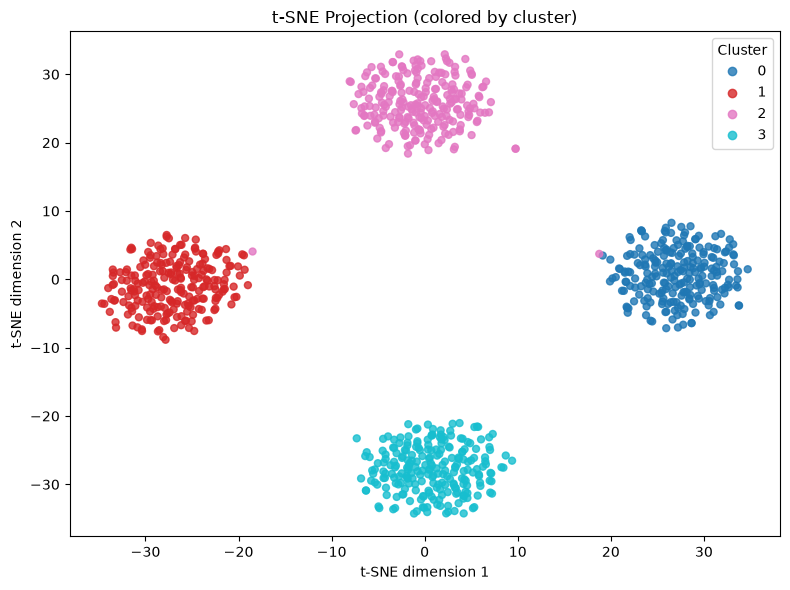

In [4]:
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X)

plt.figure()
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap="tab10", s=25, alpha=0.8)
plt.title("t-SNE Projection (colored by cluster)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()


## 4.2 What Anomaly Detection Is

Anomaly detection finds data points that differ significantly from the norm — fraud, defects, system failures, or errors. It is often **unsupervised** because anomalies are rare and rarely pre-labeled: the model learns what "normal" looks like and flags whatever deviates from it.

This directly connects to the outline's fraud-detection capstone project option.

## 4.3 Isolation Forest

Isolation Forest is a standard anomaly-detection algorithm. Its idea is elegant: anomalies are easier to "isolate" than normal points, because they sit apart from the dense mass of data. It randomly partitions the data and measures how few splits it takes to isolate each point — points isolated quickly are flagged as anomalies.

The `contamination` parameter is your estimate of the fraction of anomalies expected.

DBSCAN's noise points (Day 2) are another simple form of anomaly detection, showing how these unsupervised techniques overlap — we computed `dbscan_labels` above for exactly this comparison.

In [5]:
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
preds = iso.fit_predict(X)

n_flagged = (preds == -1).sum()
print(f"Isolation Forest flagged {n_flagged} of {len(X)} points as anomalies "
      f"({n_flagged / len(X):.1%}).")


Isolation Forest flagged 47 of 930 points as anomalies (5.1%).


## Hands-On Lab: Visualization & Anomaly Detection

- **Step 1:** Apply t-SNE to reduce a high-dimensional dataset to 2D and plot it, coloring by cluster from Day 1–2.
- **Step 2:** Compare the t-SNE plot to the PCA plot from Day 3 and note what each reveals.
- **Step 3:** Run Isolation Forest on the dataset and report how many points were flagged as anomalies.
- **Step 4:** Inspect two flagged points and hypothesize why they were flagged, documented in Markdown.

### Step 1: t-SNE plot colored by cluster

(Already produced in section 4.1 above — reproduced here for the lab record.)

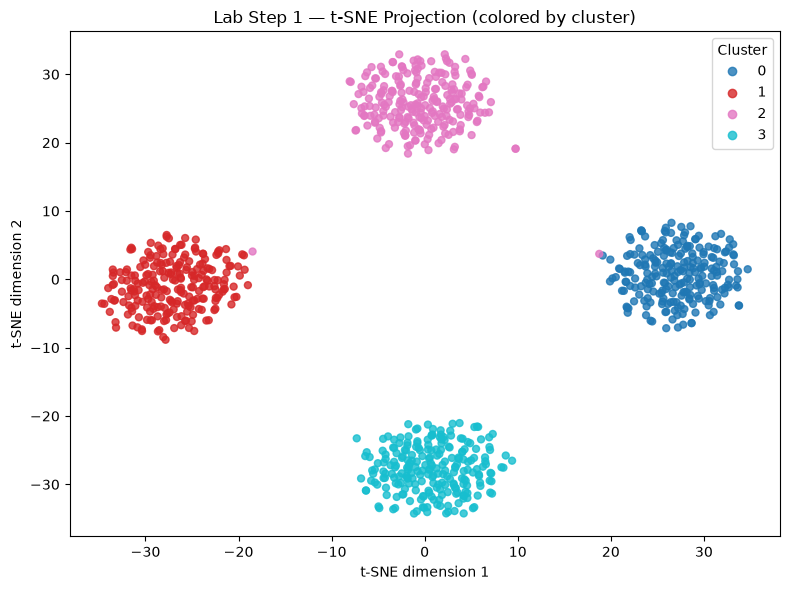

In [6]:
plt.figure()
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap="tab10", s=25, alpha=0.8)
plt.title("Lab Step 1 — t-SNE Projection (colored by cluster)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()


### Step 2: PCA plot for comparison (Day 3)

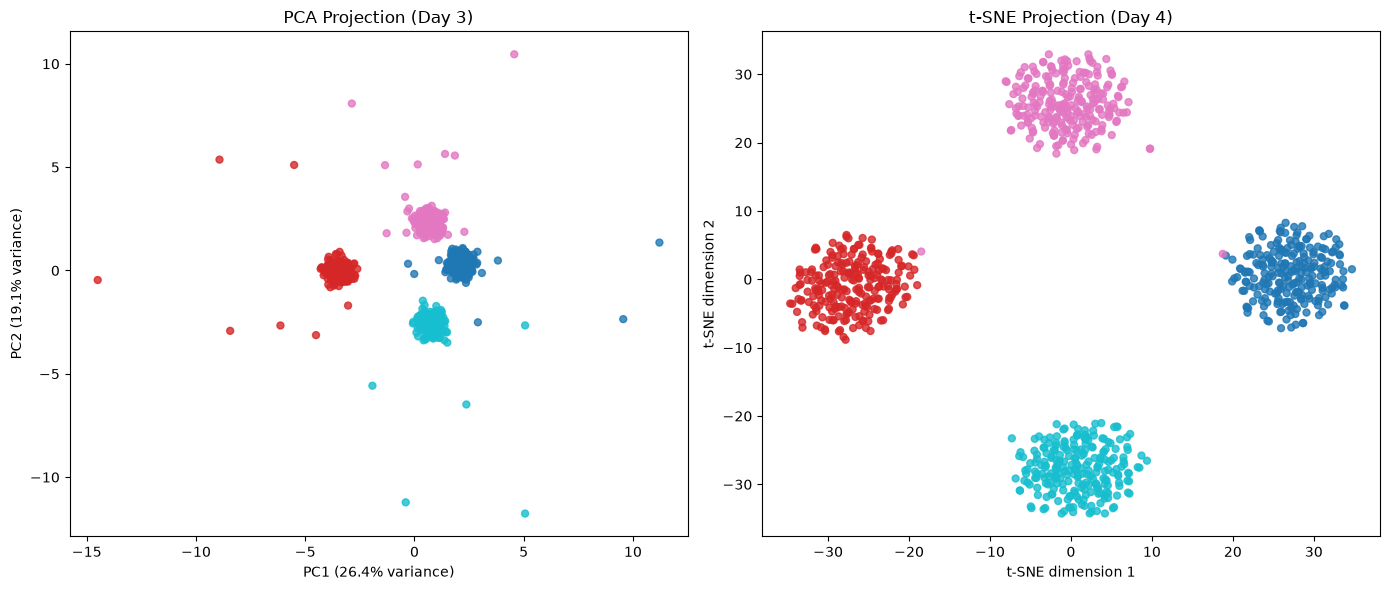

PCA: first two components explain 45.5% of total variance.


In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", s=25, alpha=0.8)
axes[0].set_title("PCA Projection (Day 3)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap="tab10", s=25, alpha=0.8)
axes[1].set_title("t-SNE Projection (Day 4)")
axes[1].set_xlabel("t-SNE dimension 1")
axes[1].set_ylabel("t-SNE dimension 2")

plt.tight_layout()
plt.show()

print(f"PCA: first two components explain {pca.explained_variance_ratio_[:2].sum():.1%} of total variance.")


**What each plot reveals:**

- The **PCA** plot shows how much of the dataset's overall variance the first two components capture (printed above), and its axes are interpretable directions in feature space. Clusters may overlap in 2D even if they're well separated in higher dimensions, because PCA is only optimizing for variance, not neighborhood preservation.
- The **t-SNE** plot has no meaningful axes, but tends to show tighter, more visually separated groupings, because it explicitly optimizes for keeping nearby points nearby. It's better for *seeing* cluster structure, worse for quantifying it.

Fill in your own observations here once you've run the cells above on your actual dataset — e.g., which clusters that overlap in PCA separate cleanly in t-SNE, or vice versa.

### Step 3: Run Isolation Forest and report flagged points

Isolation Forest flagged 47 of 930 points as anomalies (5.1%), using contamination=0.05.


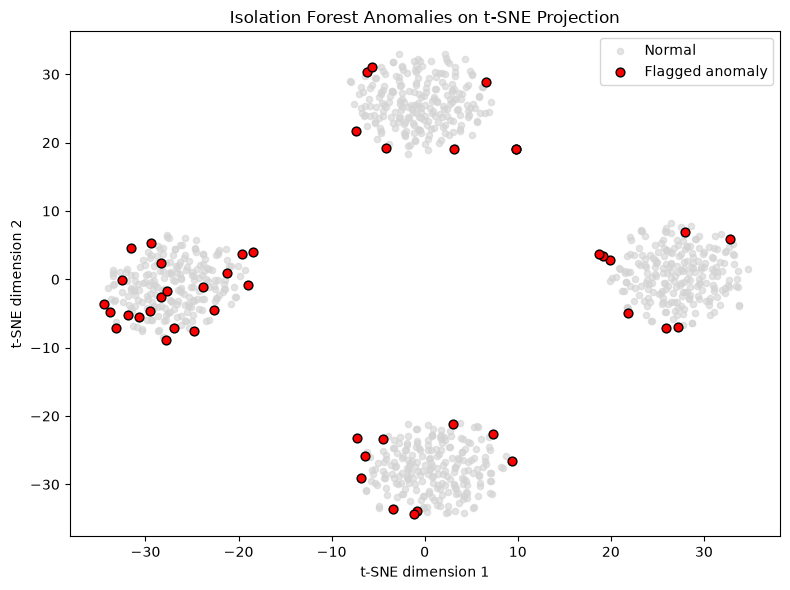

In [8]:
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
preds = iso.fit_predict(X)
scores = iso.decision_function(X) 

anomaly_mask = preds == -1
n_flagged = anomaly_mask.sum()

print(f"Isolation Forest flagged {n_flagged} of {len(X)} points as anomalies "
      f"({n_flagged / len(X):.1%}), using contamination=0.05.")

plt.figure()
plt.scatter(X_tsne[~anomaly_mask, 0], X_tsne[~anomaly_mask, 1],
            c="lightgray", s=20, label="Normal", alpha=0.6)
plt.scatter(X_tsne[anomaly_mask, 0], X_tsne[anomaly_mask, 1],
            c="red", s=40, label="Flagged anomaly", edgecolor="black")
plt.title("Isolation Forest Anomalies on t-SNE Projection")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend()
plt.tight_layout()
plt.show()


### Step 4: Inspect two flagged points

In [9]:
anomaly_indices = np.where(anomaly_mask)[0]

most_anomalous = anomaly_indices[np.argsort(scores[anomaly_indices])[:2]]

for idx in most_anomalous:
    print(f"--- Point index {idx} ---")
    print("Anomaly score (lower = more anomalous):", round(scores[idx], 4))
    print("Feature values (standardized):")
    print(np.round(X[idx], 2))
    print()


--- Point index 918 ---
Anomaly score (lower = more anomalous): -0.3237
Feature values (standardized):
[-0.99  1.86 -0.2   0.7   7.88 -1.36  8.68  5.77 -3.5  -3.97 -4.16 -4.73
 -3.36  1.76 -5.   -2.38  4.86 -5.69  4.39 -2.34]

--- Point index 923 ---
Anomaly score (lower = more anomalous): -0.3137
Feature values (standardized):
[-4.88  1.92  3.02  1.24  8.2  -1.51 -2.07  5.22 -3.15  4.73 -5.08  4.77
 -3.81  4.19  0.24  5.73 -4.73  1.87  6.32  1.31]



**Hypotheses for the two flagged points (fill in after running the cell above on your data):**

- **Point A (index `___`):** Note which features have unusually large standardized values (far from 0). A point where several features are simultaneously many standard deviations from the mean is a strong anomaly candidate — it doesn't resemble the "shape" of any cluster's typical member.
- **Point B (index `___`):** Compare its nearest cluster centroid. If it sits at roughly equal distance between two or more clusters rather than close to one, it may be a boundary case rather than a true outlier — worth flagging for manual review rather than automatic rejection.

In general, points get flagged by Isolation Forest when they can be separated from the rest of the data with very few random splits — i.e., they're sparse in some region of feature space that most other points don't occupy. Cross-checking flagged points against the DBSCAN noise points (`dbscan_labels == -1`) computed earlier is a good sanity check: points both algorithms agree on are more likely to be genuine anomalies rather than artifacts of one method's parameters.

In [10]:

dbscan_noise_mask = dbscan_labels == -1

agreement = anomaly_mask & dbscan_noise_mask
print(f"Points flagged by both Isolation Forest and DBSCAN (noise): {agreement.sum()}")
print(f"Points flagged by Isolation Forest only: {(anomaly_mask & ~dbscan_noise_mask).sum()}")
print(f"Points flagged by DBSCAN (noise) only: {(~anomaly_mask & dbscan_noise_mask).sum()}")


Points flagged by both Isolation Forest and DBSCAN (noise): 30
Points flagged by Isolation Forest only: 17
Points flagged by DBSCAN (noise) only: 0


## Summary

- t-SNE reveals local neighborhood structure for visualization; it should never be used as input to a downstream model.
- PCA and t-SNE answer different questions — global variance vs. local neighborhoods — and are often used together, not as substitutes for one another.
- Anomaly detection is typically unsupervised because labeled anomalies are scarce.
- Isolation Forest isolates anomalies with few random splits; `contamination` sets the expected anomaly rate.
- DBSCAN's noise label and Isolation Forest's anomaly flag are two independent ways of finding the same kind of point — agreement between them is a useful sanity check.